In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv('student_data.csv')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


| Column | English Definition | Data Type | Category |
|---|---|---|---|
| school | Student's school | Categorical | Nominal |
| sex | Student's gender | Categorical | Nominal |
| age | Student's age (in years) | Numerical | Discrete |
| address | Type of student's home address | Categorical | Nominal |
| famsize | Family size | Categorical | Nominal |
| Pstatus | Parent's cohabitation status | Categorical | Nominal |
| Medu | Mother's education level | Ordinal | Ordinal |
| Fedu | Father's education level | Ordinal | Ordinal |
| Mjob | Mother's job | Categorical | Nominal |
| Fjob | Father's job | Categorical | Nominal |
| reason | Reason to choose this school | Categorical | Nominal |
| guardian | Student's guardian | Categorical | Nominal |
| traveltime | Home to school travel time | Ordinal | Ordinal |
| studytime | Weekly study time | Ordinal | Ordinal |
| failures | Number of past class failures | Numerical | Discrete |
| schoolsup | Extra educational support from school | Categorical | Binary |
| famsup | Family educational support | Categorical | Binary |
| paid | Extra paid classes within the course subject | Categorical | Binary |
| activities | Extra-curricular activities | Categorical | Binary |
| nursery | Attended nursery school | Categorical | Binary |
| higher | Wants to take higher education | Categorical | Binary |
| internet | Internet access at home | Categorical | Binary |
| romantic | With a romantic relationship | Categorical | Binary |
| famrel | Quality of family relationships | Ordinal | Ordinal |
| freetime | Free time after school | Ordinal | Ordinal |
| goout | Going out with friends | Ordinal | Ordinal |
| Dalc | Workday alcohol consumption | Ordinal | Ordinal |
| Walc | Weekend alcohol consumption | Ordinal | Ordinal |
| health | Current health status | Ordinal | Ordinal |
| absences | Number of school absences | Numerical | Discrete |
| G1 | First period grade (out of 20) | Numerical | Continuous |
| G2 | Second period grade (out of 20) | Numerical | Continuous |
| G3 | Final grade (out of 20) - Target Variable | Numerical | Continuous |

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

- no nulls 

In [4]:
df.shape

(395, 33)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
freetime,395.0,3.235443,0.998862,1.0,3.0,3.0,4.0,5.0
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
Dalc,395.0,1.481013,0.890741,1.0,1.0,1.0,2.0,5.0


- failures column has more zeros 

In [6]:
df['failures'].value_counts()


failures
0    312
1     50
2     17
3     16
Name: count, dtype: int64

In [7]:
print(df.groupby('school')['failures'].agg(['count', 'mean', 'min', 'max', 'std']).round(2))

        count  mean  min  max   std
school                             
GP        349  0.32    0    3  0.73
MS         46  0.46    0    3  0.81


- the most student failure on MS 

In [8]:
print(df.groupby('school') ['absences'].agg(['count','mean','min','max','std']))

        count      mean  min  max       std
school                                     
GP        349  5.965616    0   75  8.341764
MS         46  3.760870    0   17  4.274913


Text(0.5, 1.0, 'Distribution of Final Grades (G3)')

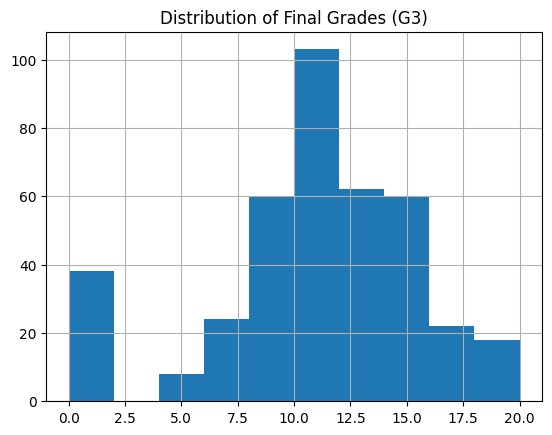

In [9]:
df['G3'].hist(bins=10)
plt.title('Distribution of Final Grades (G3)')

In [10]:
df['age'].value_counts()

age
16    104
17     98
18     82
15     82
19     24
20      3
22      1
21      1
Name: count, dtype: int64

In [11]:
df['age'] = df[df['age'] <= 19 ]['age']

In [12]:
df['age'].value_counts()

age
16.0    104
17.0     98
18.0     82
15.0     82
19.0     24
Name: count, dtype: int64

In [13]:
df.duplicated().sum()

0

In [14]:
df.isnull().sum()

school        0
sex           0
age           5
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [15]:
binary_columns = ['schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
for col in binary_columns:
    df[col] = np.where(df[col] == 'yes', 1, 0)

In [16]:
df[binary_columns].head()

,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
0,1,0,0,0,1,1,0,0
1,0,1,0,0,0,1,1,0
2,1,0,1,0,1,1,1,0
3,0,1,1,1,1,1,1,1
4,0,1,1,0,1,1,0,0


In [ ]:
df['total'] = df['G1'] + df ['G2'] + df ['G3']

In [ ]:
numeric = df.select_dtypes(include='number')

In [18]:
print (where(df[numeric].corr))

NameError: name 'where' is not defined